In [28]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

from tensorflow import keras
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import Accuracy, F1Score

import pickle

In [3]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
#df_train = df_train.sample(frac=1, random_state = 33) #shuffle the data set
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [26]:
df_train.describe() #All the features are already normalized and range between -1 and 1.

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000


In [3]:
df_train=df_train.drop(columns = ['subject'], axis=1) #drop the data of the subject that was used to measure the data

In [4]:
#We use around 20% of the training data for validation, this split is only necessary for the neural network
#since we do GridSearch CV on the other models
X_train = df_train.iloc[:6000,:-1]
y_train = df_train.iloc[:6000,-1]
X_val = df_train.iloc[6000:, :-1]
y_val = df_train.iloc[6000:,-1]
X_test = df_test.iloc[:,:-1].drop(columns = ['subject'])
y_test = df_test.iloc[:,-1]

#We one-hot encode the target label
encoder = OneHotEncoder(sparse_output = False)
y_train = encoder.fit_transform(np.array(y_train).reshape(-1,1))
y_val = encoder.transform(np.array(y_val).reshape(-1,1))
y_test = encoder.transform(np.array(y_test).reshape(-1,1))

On this first part, we perform a baseline computation of simply random guessing in order to have a baseline to compare later

In [5]:
#Baseline computation: choosing randomly among labels

y_random_pred = encoder.transform(np.array(df_test.iloc[:,-1].sample(frac =1)).reshape(-1,1)) #random prediction

def scores(y_t,y_p):

  cce = CategoricalCrossentropy()
  acc = Accuracy()
  f1_score = F1Score()

  print('Categorical crossentropy:', cce(y_t,y_p).numpy())
  print('Accuracy:', acc(np.argmax(y_t, axis=1), np.argmax(y_p,axis=1)).numpy())
  print('F1 score:', f1_score(y_t,y_p).numpy())

  # Reset the state of the metrics after each evaluation
  acc.reset_state()
  f1_score.reset_state()

print('Random choice scores for test set:')
scores(y_test,y_random_pred)

Random choice scores for test set:
Categorical crossentropy: 13.279515
Accuracy: 0.1761113
F1 score: [0.19739288 0.20366594 0.18984957 0.1633064  0.13571425 0.15711248]


In [6]:
#Model 1: Logistic regression

lr_params = {"C": [0.01, 0.1 ,1]}

lr = LogisticRegression(solver = 'saga', multi_class='auto', max_iter=1000) # Added multi_class and increased max_iter for convergence

grid_lr = GridSearchCV(lr, param_grid = lr_params, cv = 5, verbose =2)

#We include X_val and y_val since we are using GridSearchCv
grid_lr.fit(df_train.iloc[:,:-1], df_train.iloc[:,-1])

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .............................................C=0.01; total time=  11.2s
[CV] END .............................................C=0.01; total time=   2.4s
[CV] END .............................................C=0.01; total time=  18.2s
[CV] END .............................................C=0.01; total time=   3.2s
[CV] END .............................................C=0.01; total time=  13.5s
[CV] END ..............................................C=0.1; total time=  11.4s
[CV] END ..............................................C=0.1; total time=  12.7s
[CV] END ..............................................C=0.1; total time=  12.3s
[CV] END ..............................................C=0.1; total time=  13.2s
[CV] END ..............................................C=0.1; total time=  12.2s
[CV] END ................................................C=1; total time=  54.9s
[CV] END ........................................

GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, multi_class='auto',
                                          solver='saga'),
             param_grid={'C': [0.01, 0.1, 1]}, verbose=2)

In [22]:
best_lr = grid_lr.best_estimator_

with open("lr_model.pkl", "wb") as f:
    pickle.dump(best_lr, f)

#with open("lr_model.pkl", "rb") as f:
    #loaded_lr = pickle.load(f)

# Get predictions from the logistic regression model on the test set
y_test_pred_lr = best_lr.predict(X_test)

y_test_pred_lr_encoded = encoder.transform(y_test_pred_lr.reshape(-1, 1))

# Evaluate the logistic regression model on the test set using the scores function
print("Logistic Regression Scores on Test Set:")
scores(y_test, y_test_pred_lr_encoded)

Logistic Regression Scores on Test Set:
Categorical crossentropy: 0.6289722
Accuracy: 0.96097726
F1 score: [1.         0.9250535  0.93862814 0.9685658  0.97708076 0.9559613 ]


In [10]:
#Model 2: Random Forest

rf_params = {"n_estimators": [100, 200 ,300], "max_features": ['sqrt', 'log2']}

rf = RandomForestClassifier()

grid_rf = GridSearchCV(rf, param_grid = rf_params, cv = 3, verbose =2)

#We include X_val and y_val since we are using GridSearchCv
grid_rf.fit(df_train.iloc[:,:-1], df_train.iloc[:,-1])

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ................max_features=sqrt, n_estimators=100; total time=  12.6s
[CV] END ................max_features=sqrt, n_estimators=100; total time=  12.7s
[CV] END ................max_features=sqrt, n_estimators=100; total time=  12.7s
[CV] END ................max_features=sqrt, n_estimators=200; total time=  37.0s
[CV] END ................max_features=sqrt, n_estimators=200; total time=  28.1s
[CV] END ................max_features=sqrt, n_estimators=200; total time=  25.0s
[CV] END ................max_features=sqrt, n_estimators=300; total time=  37.4s
[CV] END ................max_features=sqrt, n_estimators=300; total time=  38.3s
[CV] END ................max_features=sqrt, n_estimators=300; total time=  38.1s
[CV] END ................max_features=log2, n_estimators=100; total time=   5.8s
[CV] END ................max_features=log2, n_estimators=100; total time=   5.2s
[CV] END ................max_features=log2, n_est

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 200, 300]},
             verbose=2)

In [21]:
best_rf = grid_rf.best_estimator_

with open("rf_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

#with open("lr_model.pkl", "rb") as f:
    #loaded_lr = pickle.load(f)

# Get predictions from the logistic regression model on the test set
y_test_pred_rf = best_rf.predict(X_test)

y_test_pred_rf_encoded = encoder.transform(y_test_pred_rf.reshape(-1, 1))

# Evaluate the logistic regression model on the test set using the scores function
print("Randaom Forest Scores on Test Set:")
scores(y_test, y_test_pred_rf_encoded)

Randaom Forest Scores on Test Set:
Categorical crossentropy: 1.0938647
Accuracy: 0.9321344
F1 score: [1.         0.91841    0.92844033 0.93592227 0.88407636 0.9092805 ]


In [30]:
#Model 3: Support Vector Machine

svm_params = {"C": [0.01, 0.1, 1], "kernel": ['linear', 'rbf', 'poly']}

svm = SVC()

grid_svm = GridSearchCV(svm, param_grid = svm_params, cv = 3, verbose =2)

#We include X_val and y_val since we are using GridSearchCv
grid_svm.fit(df_train.iloc[:,:-1], df_train.iloc[:,-1])


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ..............................C=0.01, kernel=linear; total time=   1.6s
[CV] END ..............................C=0.01, kernel=linear; total time=   1.5s
[CV] END ..............................C=0.01, kernel=linear; total time=   1.6s
[CV] END .................................C=0.01, kernel=rbf; total time=  13.5s
[CV] END .................................C=0.01, kernel=rbf; total time=  14.1s
[CV] END .................................C=0.01, kernel=rbf; total time=  22.3s
[CV] END ................................C=0.01, kernel=poly; total time=   7.8s
[CV] END ................................C=0.01, kernel=poly; total time=   5.0s
[CV] END ................................C=0.01, kernel=poly; total time=   5.2s
[CV] END ...............................C=0.1, kernel=linear; total time=   1.1s
[CV] END ...............................C=0.1, kernel=linear; total time=   1.1s
[CV] END ...............................C=0.1, ke

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf', 'poly']},
             verbose=2)

In [31]:
best_svm = grid_svm.best_estimator_

with open("svm_model.pkl", "wb") as f:
    pickle.dump(best_svm, f)

#with open("lr_model.pkl", "rb") as f:
    #loaded_lr = pickle.load(f)

# Get predictions from the logistic regression model on the test set
y_test_pred_svm = best_svm.predict(X_test)

y_test_pred_svm_encoded = encoder.transform(y_test_pred_svm.reshape(-1, 1))

# Evaluate the logistic regression model on the test set using the scores function
print("Randaom Forest Scores on Test Set:")
scores(y_test, y_test_pred_svm_encoded)

Randaom Forest Scores on Test Set:
Categorical crossentropy: 0.5797483
Accuracy: 0.9640312
F1 score: [1.         0.92356676 0.9364791  0.9742574  0.9820358  0.9688506 ]


We now try with neural network. One using the full set of features, and another using a dimensionally reduced set of features coming from an autoencoder

In [12]:
#Model 4: Sequential Neural Network
optimizer = RMSprop(learning_rate = 0.0001) #this seemed like a good learning rate after several tries

In [13]:
model = Sequential()
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(6, activation = 'softmax'))

model.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics =['Accuracy'])

In [14]:
early_stopping = EarlyStopping(monitor = 'val_Accuracy', patience = 20, restore_best_weights =True )
model_check = ModelCheckpoint(filepath = 'bestmodel.model.keras', monitor = 'val_loss', save_best_only= True)

In [15]:
history = model.fit(X_train, y_train, epochs = 120, batch_size = 128, validation_data = (X_val,y_val),
                    callbacks = [early_stopping, model_check])

Epoch 1/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - Accuracy: 0.2445 - loss: 1.7096 - val_Accuracy: 0.6612 - val_loss: 1.3203
Epoch 2/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - Accuracy: 0.4445 - loss: 1.3566 - val_Accuracy: 0.7448 - val_loss: 1.0367
Epoch 3/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5497 - loss: 1.1286 - val_Accuracy: 0.7596 - val_loss: 0.8334
Epoch 4/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.6204 - loss: 0.9492 - val_Accuracy: 0.8417 - val_loss: 0.6810
Epoch 5/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - Accuracy: 0.6845 - loss: 0.8149 - val_Accuracy: 0.8180 - val_loss: 0.5656
Epoch 6/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.7231 - loss: 0.6877 - val_Accuracy: 0.8854 - val_loss: 0.4768
Epoch 7/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - Accuracy: 0.7431 - loss: 0.6237 - val_Accuracy: 0.8950 - val_loss: 0.4126
Epoch 8/120
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - Accuracy: 0.7758 - loss: 0.5478 - val_Accuracy: 0.9009 - 

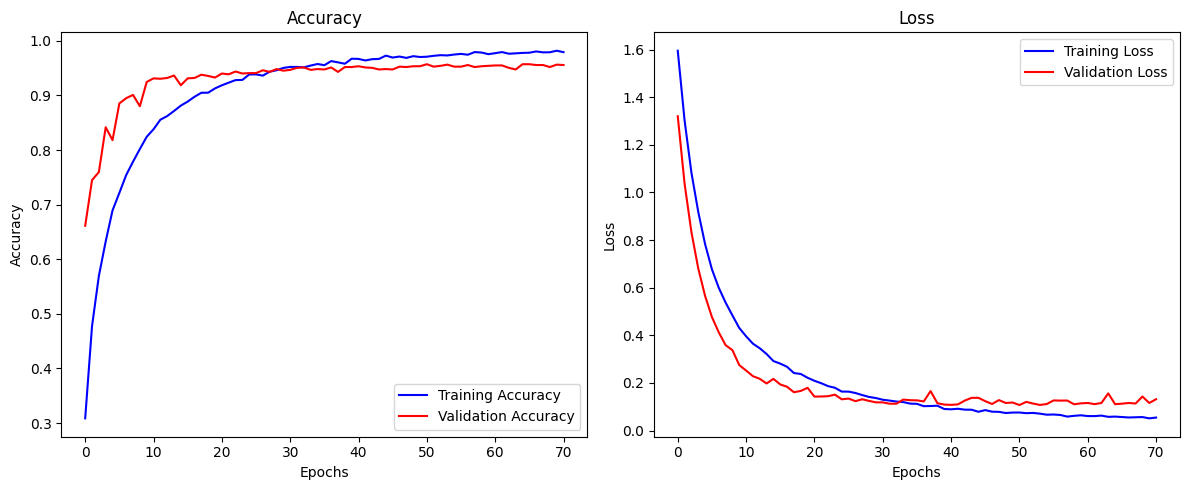

In [18]:
epochs = len(history.history['loss'])
def plot_loss_acc(n_epochs, loss_history,val_loss_history, acc, val_acc):
  # Create a figure and a set of subplots (1 row, 2 columns)
  fig, ax = plt.subplots(1, 2, figsize=(12, 5))

  # Plot Accuracy on the first subplot
  ax[0].plot(range(n_epochs), acc,'b', label='Training Accuracy')
  ax[0].plot(range(n_epochs), val_acc,'r', label='Validation Accuracy')
  ax[0].set_title('Accuracy') # Set title on the axis
  ax[0].set_xlabel('Epochs')
  ax[0].set_ylabel('Accuracy')
  ax[0].legend()


  # Plot Loss on the second subplot
  ax[1].plot(range(n_epochs), loss_history,'b', label='Training Loss')
  ax[1].plot(range(n_epochs), val_loss_history,'r', label='Validation Loss')
  ax[1].set_title('Loss') # Set title on the axis
  ax[1].set_xlabel('Epochs')
  ax[1].set_ylabel('Loss')
  ax[1].legend()

  plt.tight_layout()


# Call the plotting function
plot_loss_acc(epochs, history.history['loss'], history.history['val_loss'],
              history.history['Accuracy'], history.history['val_Accuracy'])

plt.show()

In [19]:
best_model = keras.models.load_model('bestmodel.model.keras')

In [20]:
best_model.evaluate(X_val,y_val)[0]

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.9600 - loss: 0.1002


0.10721807926893234

In [27]:
y_pred = best_model.predict(X_test)
print("NN scores on Test set:")
scores(y_test,y_pred)
print("Logistic Regression Scores on Test Set:")
scores(y_test, y_test_pred_lr_encoded)
print("Random Forest Scores on Test Set:")
scores(y_test, y_test_pred_rf_encoded)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
NN scores on Test set:
Categorical crossentropy: 0.16877241
Accuracy: 0.9395996
F1 score: [0.9934395  0.90835845 0.9092628  0.9461312  0.9472421  0.93159604]
Logistic Regression Scores on Test Set:
Categorical crossentropy: 0.6289722
Accuracy: 0.96097726
F1 score: [1.         0.9250535  0.93862814 0.9685658  0.97708076 0.9559613 ]
Random Forest Scores on Test Set:
Categorical crossentropy: 1.0938647
Accuracy: 0.9321344
F1 score: [1.         0.91841    0.92844033 0.93592227 0.88407636 0.9092805 ]
